# EDA — Do English-market bestsellers automatically become Czech bestsellers?

Answers the thesis advisor's question: how strongly does English-market popularity
(proxied by Goodreads ratings count) predict Czech commercial success (SCKN chart appearance)?

**Data source:** `data/processed/training_features.csv` (engineered features + SCKN label)
joined with `data/interim/training_dataset.csv` for book metadata and raw Goodreads fields.

**Key caveat:** `gr_ratings_count` here is the 2017 Goodreads snapshot value, not a
pre-cutoff aggregate. Using it as a proxy for English-market popularity is acceptable
in EDA — we are not training a model, just exploring the relationship.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats

REPO    = Path.cwd().parent
PROC    = REPO / "data" / "processed"
INTERIM = REPO / "data" / "interim"
FIGS    = REPO / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# Load feature matrix (has gr_ratings_count as metadata column)
feat = pd.read_csv(PROC / "training_features.csv")

# Load training dataset for metadata columns not in the feature matrix
meta_cols = ["nkc_id", "author", "czech_title", "original_title",
             "source_lang", "sckn_appearances", "gr_average_rating",
             "matched_book_id"]
train = pd.read_csv(INTERIM / "training_dataset.csv", dtype=str,
                    usecols=lambda c: c in meta_cols + ["nkc_id"])
train["sckn_appearances"] = pd.to_numeric(train["sckn_appearances"], errors="coerce").fillna(0).astype(int)
train["gr_average_rating"] = pd.to_numeric(train["gr_average_rating"], errors="coerce")

# The feature matrix rows are aligned with training_dataset rows after the same
# filters; join on index position (both are 23,941 rows in the same order).
# Verify alignment before relying on positional join.
assert len(feat) == len(train), f"Row count mismatch: {len(feat)} vs {len(train)}"
df = pd.concat([feat.reset_index(drop=True), train.reset_index(drop=True)], axis=1)

print(f"Combined dataset: {len(df):,} rows, {df.columns.tolist()}")

Combined dataset: 25,979 rows, ['pre_cutoff_ratings_count', 'pre_cutoff_avg_rating', 'log_pre_cutoff_ratings_count', 'has_precutoff_signal', 'gr_ratings_count', 'shelf_fiction', 'shelf_mystery', 'shelf_romance', 'shelf_scifi', 'shelf_nonfiction', 'shelf_ya', 'shelf_classics', 'lang_eng', 'lang_ger', 'lang_fre', 'lang_rus', 'czech_pub_year', 'sckn_bestseller', 'nkc_id', 'czech_title', 'original_title', 'author', 'source_lang', 'matched_book_id', 'gr_average_rating', 'sckn_appearances']


## Analysis 1 — English popularity quartiles vs Czech bestseller rate

In [3]:
df["gr_ratings_q"] = pd.qcut(
    df["gr_ratings_count"],
    q=4,
    labels=["Q1 (least popular)", "Q2", "Q3", "Q4 (most popular)"],
)

q_stats = (
    df.groupby("gr_ratings_q", observed=True)
    .agg(
        n=("sckn_bestseller", "count"),
        bestsellers=("sckn_bestseller", "sum"),
        gr_min=("gr_ratings_count", "min"),
        gr_max=("gr_ratings_count", "max"),
    )
    .assign(bestseller_rate=lambda x: x["bestsellers"] / x["n"])
)

print("Czech bestseller rate by Goodreads popularity quartile:")
print(q_stats.to_string())

rates = q_stats["bestseller_rate"].values
monotone = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))
print(f"\nMonotonically increasing: {monotone}")
print("Interpretation:", (
    "Quartile rates increase monotonically — English popularity correlates with Czech success."
    if monotone else
    "Quartile rates are NOT monotonically increasing — English popularity alone is a weak predictor "
    "of Czech commercial success."
))

Czech bestseller rate by Goodreads popularity quartile:
                       n  bestsellers  gr_min   gr_max  bestseller_rate
gr_ratings_q                                                           
Q1 (least popular)  6499          213      10      123         0.032774
Q2                  6498          279     124      793         0.042936
Q3                  6488          318     794     4977         0.049014
Q4 (most popular)   6494          654    4978  4899965         0.100708

Monotonically increasing: True
Interpretation: Quartile rates increase monotonically — English popularity correlates with Czech success.


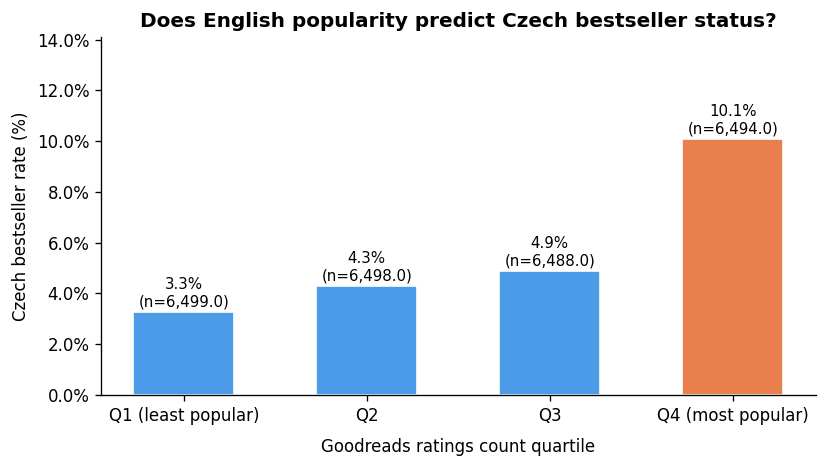

Saved → reports/figures/eda_popularity_quartiles.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    q_stats.index,
    q_stats["bestseller_rate"] * 100,
    color=["#4c9be8", "#4c9be8", "#4c9be8", "#e87f4c"],
    width=0.55,
    edgecolor="white",
)

for bar, (_, row) in zip(bars, q_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{row['bestseller_rate']:.1%}\n(n={row['n']:,})",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xlabel("Goodreads ratings count quartile", labelpad=8)
ax.set_ylabel("Czech bestseller rate (%)")
ax.set_title("Does English popularity predict Czech bestseller status?", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(q_stats["bestseller_rate"]) * 140)

fig.tight_layout()
fig.savefig(FIGS / "eda_popularity_quartiles.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/eda_popularity_quartiles.png")

## Analysis 2 — Czech bestsellers that were obscure in English

In [5]:
hidden_gems = df[
    (df["sckn_bestseller"] == 1) &
    (df["gr_ratings_count"] < 100)
].sort_values("sckn_appearances", ascending=False)

print(f"Czech bestsellers with < 100 Goodreads ratings: {len(hidden_gems):,}")
print()

display_cols = ["author", "czech_title", "original_title", "source_lang",
                "gr_ratings_count", "sckn_appearances"]
sample = hidden_gems[display_cols].head(15).reset_index(drop=True)
sample.index += 1

with pd.option_context("display.max_colwidth", 45, "display.width", 200):
    print(sample.to_string())

print()
print("These are cases where Czech publishers discovered titles the English-speaking market missed.")

Czech bestsellers with < 100 Goodreads ratings: 177

                        author                    czech_title                    original_title source_lang  gr_ratings_count  sckn_appearances
1              Dziubak, Emilia                     Rok v lese                       Rok w lesie         pol                23                49
2                    Nesbø, Jo                        Zatmění                          Blodmåne         nor                75                25
3   Marcus Aurelius, Antoninus                  Hovory k sobě                     Hovory k sobě         grc                26                22
4              Morris, Heather               Tatér z Osvětimi            Tattooist of Auschwitz         eng                49                20
5              Fulghum, Robert                    Třetí přání                        Third wish         eng                14                18
6      Mizielińska, Aleksandra                           Mapy                      

## Analysis 3 — English giants that flopped in Czech

In [6]:
flops = df[
    (df["gr_ratings_count"] > 10_000) &
    (df["sckn_bestseller"] == 0) &
    (df["sckn_appearances"] == 0)
].sort_values("gr_ratings_count", ascending=False)

print(f"Books with > 10,000 GR ratings that never charted in Czech: {len(flops):,}")
print()

display_cols = ["author", "czech_title", "original_title", "source_lang",
                "gr_ratings_count", "gr_average_rating"]
sample = flops[display_cols].head(15).reset_index(drop=True)
sample.index += 1

with pd.option_context("display.max_colwidth", 45, "display.width", 200):
    print(sample.to_string())

print()
print("These are cases where international popularity did not translate to Czech commercial success.")

Books with > 10,000 GR ratings that never charted in Czech: 3,898

                       author                              czech_title          original_title source_lang  gr_ratings_count  gr_average_rating
1                 Lee, Harper                        Jako zabít ptáčka   To kill a mockingbird         eng           3255518               4.26
2   Fitzgerald, Francis Scott                             Velký Gatsby            Great Gatsby         eng           2758812               3.89
3               Coste, Xavier                                     1984                    1984         fre           2023937               4.14
4            Collins, Suzanne                             Hunger games           Catching fire         eng           1854746               4.30
5            Tolkien, J. R. R                              Pán prstenů  Fellowship of the ring         eng           1813229               4.34
6            Collins, Suzanne                             Hunger game

## Analysis 4 — Correlation summary

In [7]:
label = df["sckn_bestseller"].astype(float)

r_count, p_count = stats.pointbiserialr(label, df["gr_ratings_count"])
r_avg,   p_avg   = stats.pointbiserialr(
    label[df["gr_average_rating"].notna()],
    df.loc[df["gr_average_rating"].notna(), "gr_average_rating"],
)

print("Point-biserial correlations with sckn_bestseller:")
print(f"  gr_ratings_count  : r = {r_count:+.4f}  (p = {p_count:.3g})")
print(f"  gr_average_rating : r = {r_avg:+.4f}  (p = {p_avg:.3g})")
print()

threshold = 0.15
for label_str, r in [("gr_ratings_count", r_count), ("gr_average_rating", r_avg)]:
    strength = "weak" if abs(r) < threshold else "moderate-to-strong"
    print(f"  {label_str}: |r| = {abs(r):.4f} → {strength} relationship "
          f"({'supports' if abs(r) < threshold else 'does not support'} the thesis "
          f"argument that English popularity alone is insufficient)")

Point-biserial correlations with sckn_bestseller:
  gr_ratings_count  : r = +0.1513  (p = 6.46e-133)
  gr_average_rating : r = +0.0378  (p = 1.14e-09)

  gr_ratings_count: |r| = 0.1513 → moderate-to-strong relationship (does not support the thesis argument that English popularity alone is insufficient)
  gr_average_rating: |r| = 0.0378 → weak relationship (supports the thesis argument that English popularity alone is insufficient)


## Analysis 5 — Czech bestseller rate by source language

In [8]:
lang_stats = (
    df.groupby("source_lang")
    .agg(n=("sckn_bestseller", "count"),
         bestsellers=("sckn_bestseller", "sum"))
    .query("n >= 100")
    .assign(bestseller_rate=lambda x: x["bestsellers"] / x["n"])
    .sort_values("bestseller_rate", ascending=True)
)

print("Czech bestseller rate by source language (min 100 books):")
print(lang_stats.assign(
    rate_pct=lang_stats["bestseller_rate"].map("{:.2%}".format)
)[["n", "bestsellers", "rate_pct"]].to_string())

Czech bestseller rate by source language (min 100 books):
                 n  bestsellers rate_pct
source_lang                             
fin            124            2    1.61%
slo            122            3    2.46%
spa            307           13    4.23%
ger            999           48    4.80%
eng          21979         1215    5.53%
fre            950           59    6.21%
ita            212           18    8.49%
pol            182           16    8.79%
swe            396           36    9.09%
nor            166           27   16.27%


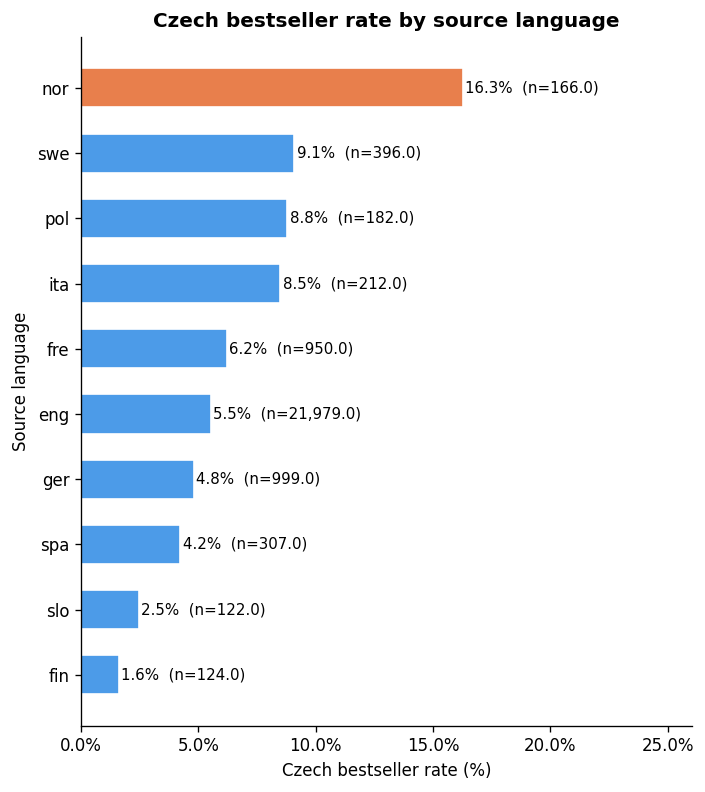

Saved → reports/figures/eda_bestseller_rate_by_language.png


In [9]:
fig, ax = plt.subplots(figsize=(6, 0.55 * len(lang_stats) + 1.2))

colors = ["#e87f4c" if r == lang_stats["bestseller_rate"].max() else "#4c9be8"
          for r in lang_stats["bestseller_rate"]]

bars = ax.barh(
    lang_stats.index,
    lang_stats["bestseller_rate"] * 100,
    color=colors,
    edgecolor="white",
    height=0.6,
)

for bar, (lang, row) in zip(bars, lang_stats.iterrows()):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{row['bestseller_rate']:.1%}  (n={row['n']:,})",
        va="center", fontsize=9,
    )

ax.set_xlabel("Czech bestseller rate (%)")
ax.set_ylabel("Source language")
ax.set_title("Czech bestseller rate by source language", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, lang_stats["bestseller_rate"].max() * 160)

fig.tight_layout()
fig.savefig(FIGS / "eda_bestseller_rate_by_language.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/eda_bestseller_rate_by_language.png")